In [1]:
import pandas as pd 
import pycld2 as cld2
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
import nltk
import geopandas as gep
import matplotlib.pyplot as plt
import plotly.express as px
import mapclassify
nltk.download("vader_lexicon")
import seaborn as sns
from nltk.sentiment.vader import SentimentIntensityAnalyzer
nltk.download('punkt_tab')      
nltk.download('wordnet')    
nltk.download('omw-1.4') 
nltk.download('averaged_perceptron_tagger_eng') 
sid_obj = SentimentIntensityAnalyzer()
lemmatizer = WordNetLemmatizer()


[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\nhuyn\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\nhuyn\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\nhuyn\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\nhuyn\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\nhuyn\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


In [3]:
trump_tweets = pd.read_csv("./data/hashtag_donaldtrump.csv", lineterminator='\n', parse_dates=True)
jb_tweets = pd.read_csv("./hdata/ashtag_joebiden.csv", lineterminator='\n', parse_dates=True)
trump_tweets['presidential_candidate'] = 'trump'
jb_tweets['presidential_candidate'] = 'biden'
merged_tweets = pd.concat([trump_tweets, jb_tweets])


In [4]:
merged_copy = merged_tweets.copy()

In [5]:
trump_tweets.head()

,created_at,tweet_id,tweet,likes,retweet_count,source,user_id,user_name,user_screen_name,user_description,...,user_location,lat,long,city,country,continent,state,state_code,collected_at,presidential_candidate
0,2020-10-15 00:00:01,1.316529e+18,#Elecciones2020 | En #Florida: #JoeBiden dice ...,0.0,0.0,TweetDeck,3.606665e+08,El Sol Latino News,elsollatinonews,🌐 Noticias de interés para latinos de la costa...,...,"Philadelphia, PA / Miami, FL",25.774270,-80.193660,NaN,United States of America,North America,Florida,FL,2020-10-21 00:00:00,trump
1,2020-10-15 00:00:01,1.316529e+18,"Usa 2020, Trump contro Facebook e Twitter: cop...",26.0,9.0,Social Mediaset,3.316176e+08,Tgcom24,MediasetTgcom24,Profilo ufficiale di Tgcom24: tutte le notizie...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2020-10-21 00:00:00.373216530,trump
2,2020-10-15 00:00:02,1.316529e+18,"#Trump: As a student I used to hear for years,...",2.0,1.0,Twitter Web App,8.436472e+06,snarke,snarke,"Will mock for food! Freelance writer, blogger,...",...,Portland,45.520247,-122.674195,Portland,United States of America,North America,Oregon,OR,2020-10-21 00:00:00.746433060,trump
3,2020-10-15 00:00:02,1.316529e+18,2 hours since last tweet from #Trump! Maybe he...,0.0,0.0,Trumpytweeter,8.283556e+17,Trumpytweeter,trumpytweeter,"If he doesn't tweet for some time, should we b...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2020-10-21 00:00:01.119649591,trump
4,2020-10-15 00:00:08,1.316529e+18,You get a tie! And you get a tie! #Trump ‘s ra...,4.0,3.0,Twitter for iPhone,4.741380e+07,Rana Abtar - رنا أبتر,Ranaabtar,"Washington Correspondent, Lebanese-American ,c...",...,Washington DC,38.894992,-77.036558,Washington,United States of America,North America,District of Columbia,DC,2020-10-21 00:00:01.492866121,trump


In [6]:
jb_tweets.head()

,created_at,tweet_id,tweet,likes,retweet_count,source,user_id,user_name,user_screen_name,user_description,...,user_location,lat,long,city,country,continent,state,state_code,collected_at,presidential_candidate
0,2020-10-15 00:00:01,1.316529e+18,#Elecciones2020 | En #Florida: #JoeBiden dice ...,0.0,0.0,TweetDeck,3.606665e+08,El Sol Latino News,elsollatinonews,🌐 Noticias de interés para latinos de la costa...,...,"Philadelphia, PA / Miami, FL",25.774270,-80.193660,NaN,United States of America,North America,Florida,FL,2020-10-21 00:00:00,biden
1,2020-10-15 00:00:18,1.316529e+18,#HunterBiden #HunterBidenEmails #JoeBiden #Joe...,0.0,0.0,Twitter for iPad,8.099044e+08,Cheri A. 🇺🇸,Biloximeemaw,"Locked and loaded Meemaw. Love God, my family ...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2020-10-21 00:00:00.517827283,biden
2,2020-10-15 00:00:20,1.316529e+18,@IslandGirlPRV @BradBeauregardJ @MeidasTouch T...,0.0,0.0,Twitter Web App,3.494182e+09,Flag Waver,Flag_Wavers,NaN,...,Golden Valley Arizona,46.304036,-109.171431,NaN,United States of America,North America,Montana,MT,2020-10-21 00:00:01.035654566,biden
3,2020-10-15 00:00:21,1.316529e+18,@chrislongview Watching and setting dvr. Let’s...,0.0,0.0,Twitter for iPhone,8.242596e+17,Michelle Ferg,MichelleFerg4,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2020-10-21 00:00:01.553481849,biden
4,2020-10-15 00:00:22,1.316529e+18,#censorship #HunterBiden #Biden #BidenEmails #...,1.0,0.0,Twitter Web App,1.032807e+18,the Gold State,theegoldstate,A Silicon Valley #independent #News #Media #St...,...,"California, USA",36.701463,-118.755997,NaN,United States of America,North America,California,CA,2020-10-21 00:00:02.071309132,biden


In [7]:
trump_tweets['tweet_id'].value_counts()

tweet_id
1.325483e+18    2
1.325478e+18    2
1.325264e+18    2
1.325376e+18    2
1.325264e+18    2
               ..
1.321777e+18    1
1.321777e+18    1
1.321777e+18    1
1.321777e+18    1
1.325589e+18    1
Name: count, Length: 969577, dtype: int64

In [8]:
merged_copy.drop_duplicates(subset=['tweet_id', 'user_id'],inplace=True)

In [9]:
merged_copy[['tweet_id', 'user_name']].value_counts()

tweet_id      user_name               
1.316529e+18  El Sol Latino News          1
1.324350e+18  toni tyler                  1
              Henry E. Lares              1
              kadimtarih.1                1
              Janet Werner                1
                                         ..
1.321885e+18  Abraham Turner              1
              Barbara Patterson           1
              The Purple Elephant Show    1
              Jerry                       1
1.325589e+18  Job                         1
Name: count, Length: 1522914, dtype: int64

In [10]:
merged_copy['tweet'] = merged_copy['tweet'].str.replace(r'@\S+|#\S+|https?://\S+|[^a-zA-Z\s]+', ' ', regex=True)

# Optional: Clean up the resulting double-spaces and trim edges
merged_copy['tweet'] = merged_copy['tweet'].str.replace(r'\s+', ' ', regex=True).str.strip()

In [11]:
merged_copy.head()

,created_at,tweet_id,tweet,likes,retweet_count,source,user_id,user_name,user_screen_name,user_description,...,user_location,lat,long,city,country,continent,state,state_code,collected_at,presidential_candidate
0,2020-10-15 00:00:01,1.316529e+18,En dice que solo se preocupa por l mismo El de...,0.0,0.0,TweetDeck,3.606665e+08,El Sol Latino News,elsollatinonews,🌐 Noticias de interés para latinos de la costa...,...,"Philadelphia, PA / Miami, FL",25.774270,-80.193660,NaN,United States of America,North America,Florida,FL,2020-10-21 00:00:00,trump
1,2020-10-15 00:00:01,1.316529e+18,Usa Trump contro Facebook e Twitter coprono Biden,26.0,9.0,Social Mediaset,3.316176e+08,Tgcom24,MediasetTgcom24,Profilo ufficiale di Tgcom24: tutte le notizie...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2020-10-21 00:00:00.373216530,trump
2,2020-10-15 00:00:02,1.316529e+18,As a student I used to hear for years for ten ...,2.0,1.0,Twitter Web App,8.436472e+06,snarke,snarke,"Will mock for food! Freelance writer, blogger,...",...,Portland,45.520247,-122.674195,Portland,United States of America,North America,Oregon,OR,2020-10-21 00:00:00.746433060,trump
3,2020-10-15 00:00:02,1.316529e+18,hours since last tweet from Maybe he is VERY b...,0.0,0.0,Trumpytweeter,8.283556e+17,Trumpytweeter,trumpytweeter,"If he doesn't tweet for some time, should we b...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2020-10-21 00:00:01.119649591,trump
4,2020-10-15 00:00:08,1.316529e+18,You get a tie And you get a tie s rally,4.0,3.0,Twitter for iPhone,4.741380e+07,Rana Abtar - رنا أبتر,Ranaabtar,"Washington Correspondent, Lebanese-American ,c...",...,Washington DC,38.894992,-77.036558,Washington,United States of America,North America,District of Columbia,DC,2020-10-21 00:00:01.492866121,trump


In [12]:
merged_copy.dropna(subset=['user_location', 'lat', 'long', 'city', 'country', 'state_code'], inplace=True)

In [13]:
merged_copy.drop(axis=1, columns=[
    'retweet_count', 
    'user_name', 
    'user_screen_name', 
    'user_description', 
    'source', 
    'user_id',
    'user_location',
    'user_join_date', 
    'user_followers_count',
    'collected_at',
    'state_code'
    ], inplace=True)

In [14]:
merged_copy

,created_at,tweet_id,tweet,likes,lat,long,city,country,continent,state,presidential_candidate
2,2020-10-15 00:00:02,1.316529e+18,As a student I used to hear for years for ten ...,2.0,45.520247,-122.674195,Portland,United States of America,North America,Oregon,trump
4,2020-10-15 00:00:08,1.316529e+18,You get a tie And you get a tie s rally,4.0,38.894992,-77.036558,Washington,United States of America,North America,District of Columbia,trump
11,2020-10-15 00:00:25,1.316529e+18,In is being by Twitter to manipulate a US elec...,0.0,41.875562,-87.624421,Chicago,United States of America,North America,Illinois,trump
12,2020-10-15 00:00:26,1.316529e+18,,3.0,32.717421,-117.162771,San Diego,United States of America,North America,California,trump
13,2020-10-15 00:00:31,1.316529e+18,impeachment how often amp lied,2.0,55.953346,-3.188375,City of Edinburgh,United Kingdom,Europe,Scotland,trump
...,...,...,...,...,...,...,...,...,...,...,...
776845,2020-11-08 23:56:15,1.325588e+18,Will become ubiquitous in a administration,0.0,39.952724,-75.163526,Philadelphia,United States of America,North America,Pennsylvania,biden
776847,2020-11-08 23:56:21,1.325588e+18,You moving near,0.0,39.952724,-75.163526,Philadelphia,United States of America,North America,Pennsylvania,biden
776865,2020-11-08 23:58:24,1.325589e+18,I m excited to have a FLOTUS whose vagina I ha...,0.0,38.894992,-77.036558,Washington,United States of America,North America,District of Columbia,biden
776869,2020-11-08 23:58:46,1.325589e+18,No puede ser lo como siempre sacando el cobre ...,0.0,32.501019,-116.964663,Tijuana,Mexico,North America,Baja California,biden


In [15]:
merged_copy = merged_copy.reset_index(drop=True)

In [16]:
merged_copy

,created_at,tweet_id,tweet,likes,lat,long,city,country,continent,state,presidential_candidate
0,2020-10-15 00:00:02,1.316529e+18,As a student I used to hear for years for ten ...,2.0,45.520247,-122.674195,Portland,United States of America,North America,Oregon,trump
1,2020-10-15 00:00:08,1.316529e+18,You get a tie And you get a tie s rally,4.0,38.894992,-77.036558,Washington,United States of America,North America,District of Columbia,trump
2,2020-10-15 00:00:25,1.316529e+18,In is being by Twitter to manipulate a US elec...,0.0,41.875562,-87.624421,Chicago,United States of America,North America,Illinois,trump
3,2020-10-15 00:00:26,1.316529e+18,,3.0,32.717421,-117.162771,San Diego,United States of America,North America,California,trump
4,2020-10-15 00:00:31,1.316529e+18,impeachment how often amp lied,2.0,55.953346,-3.188375,City of Edinburgh,United Kingdom,Europe,Scotland,trump
...,...,...,...,...,...,...,...,...,...,...,...
316291,2020-11-08 23:56:15,1.325588e+18,Will become ubiquitous in a administration,0.0,39.952724,-75.163526,Philadelphia,United States of America,North America,Pennsylvania,biden
316292,2020-11-08 23:56:21,1.325588e+18,You moving near,0.0,39.952724,-75.163526,Philadelphia,United States of America,North America,Pennsylvania,biden
316293,2020-11-08 23:58:24,1.325589e+18,I m excited to have a FLOTUS whose vagina I ha...,0.0,38.894992,-77.036558,Washington,United States of America,North America,District of Columbia,biden
316294,2020-11-08 23:58:46,1.325589e+18,No puede ser lo como siempre sacando el cobre ...,0.0,32.501019,-116.964663,Tijuana,Mexico,North America,Baja California,biden


In [17]:
merged_copy['created_at'] = pd.to_datetime(merged_copy['created_at'], format='mixed')
merged_copy['created_at'] = merged_copy['created_at'].dt.date

In [18]:
merged_copy['likes'].dtype

dtype('float64')

In [19]:
merged_copy['created_at'].unique()

array([datetime.date(2020, 10, 15), datetime.date(2020, 10, 16),
       datetime.date(2020, 10, 17), datetime.date(2020, 10, 18),
       datetime.date(2020, 10, 19), datetime.date(2020, 10, 20),
       datetime.date(2020, 10, 21), datetime.date(2020, 10, 22),
       datetime.date(2020, 10, 23), datetime.date(2020, 10, 24),
       datetime.date(2020, 10, 25), datetime.date(2020, 10, 26),
       datetime.date(2020, 10, 27), datetime.date(2020, 10, 28),
       datetime.date(2020, 10, 29), datetime.date(2020, 10, 30),
       datetime.date(2020, 10, 31), datetime.date(2020, 11, 1),
       datetime.date(2020, 11, 2), datetime.date(2020, 11, 3),
       datetime.date(2020, 11, 4), datetime.date(2020, 11, 5),
       datetime.date(2020, 11, 6), datetime.date(2020, 11, 7),
       datetime.date(2020, 11, 8)], dtype=object)

In [20]:
def lemmatize_and_sentiment(sentence):
    tokens = word_tokenize(sentence.lower())
    lemmatized_text = ' '.join([lemmatizer.lemmatize(word) for word in tokens])
    sentiment_dict = sid_obj.polarity_scores(lemmatized_text)
    if sentiment_dict['compound'] >= 0.05:
        return "pos"
    elif sentiment_dict['compound'] <= -0.05:
        return "neg"
    else:
        return "neu"

In [21]:
def detect_lang(sentence):
    isReliable, textBytesFound, details = cld2.detect(
        sentence
    )
    return details[0][1]

In [22]:
merged_copy['lang'] = merged_copy['tweet'].apply(detect_lang)

In [23]:
merged_copy['lang'].unique()
merged_copy = merged_copy.loc[(merged_copy['country'] == 'United States of America') & (merged_copy['lang'] == 'en')]

In [24]:
merged_copy['sentiment'] = merged_copy['tweet'].apply(lemmatize_and_sentiment)

C:\Users\nhuyn\AppData\Local\Temp\ipykernel_7792\1559997496.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_copy['sentiment'] = merged_copy['tweet'].apply(lemmatize_and_sentiment)


In [25]:
merged_copy.reset_index(drop=True, inplace=True)

In [26]:
merged_copy['sentiment']

0         pos
1         neu
2         neg
3         neu
4         neu
         ... 
144196    neg
144197    neu
144198    neu
144199    neu
144200    pos
Name: sentiment, Length: 144201, dtype: object

In [27]:
merged_copy.groupby(['lang'])['tweet_id'].count().sort_values()

lang
en    144201
Name: tweet_id, dtype: int64

In [28]:
merged_copy.groupby(['state'])['tweet_id'].count().sort_values()

state
South Dakota               11
Maine                      20
West Virginia              30
Wyoming                    37
North Dakota               39
New Hampshire              46
Delaware                   80
Montana                    82
Arkansas                  112
Vermont                   115
Rhode Island              117
Mississippi               145
Puerto Rico               146
Alaska                    159
Nebraska                  220
Iowa                      247
Kansas                    258
Connecticut               264
Utah                      342
New Mexico                353
Idaho                     400
Oklahoma                  427
Alabama                   473
South Carolina            486
Hawaii                    504
Kentucky                  591
New Jersey                747
Wisconsin                 822
Virginia                  909
Louisiana                1010
Indiana                  1075
Maryland                 1188
Minnesota                1308
Miss

In [29]:
state_tweet_count = merged_copy['state'].value_counts()

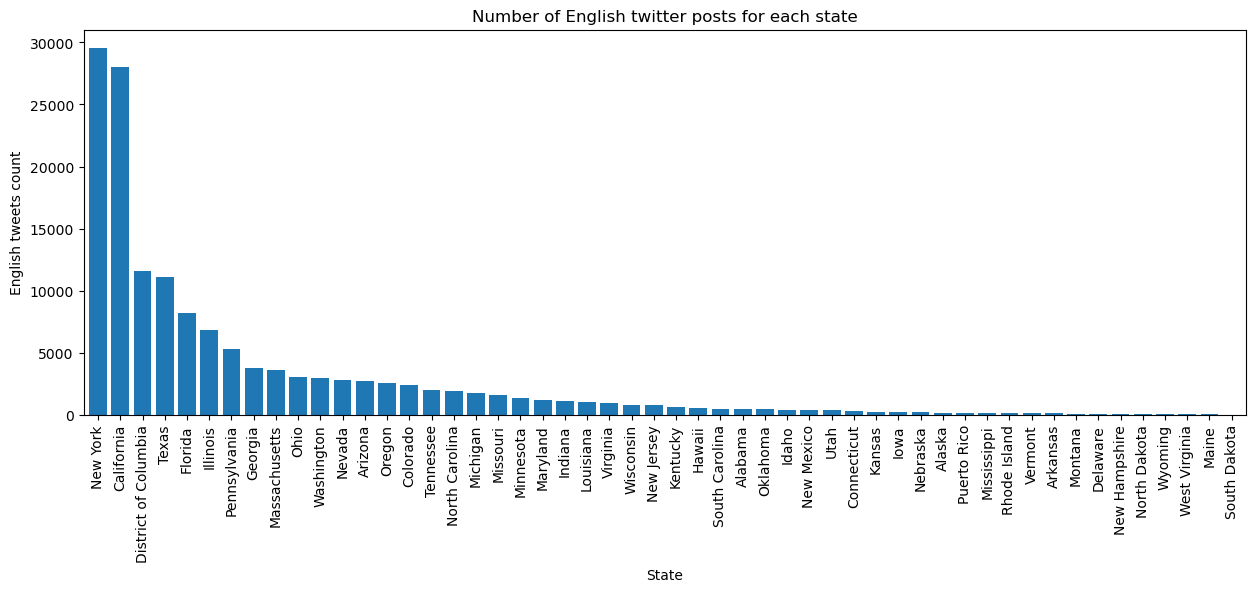

In [30]:
fig = plt.subplots(figsize =(15, 5)) 
state_tweet_count.plot(kind='bar', width=0.8)
plt.xlabel('State')
plt.ylabel('English tweets count')
plt.title('Number of English twitter posts for each state')
plt.savefig("num_english_tweets_usa")
plt.show()


In [31]:
sentiment_count = merged_copy.groupby('sentiment')['tweet_id'].count().reset_index()
sentiment_count

,sentiment,tweet_id
0,neg,46736
1,neu,33029
2,pos,64436


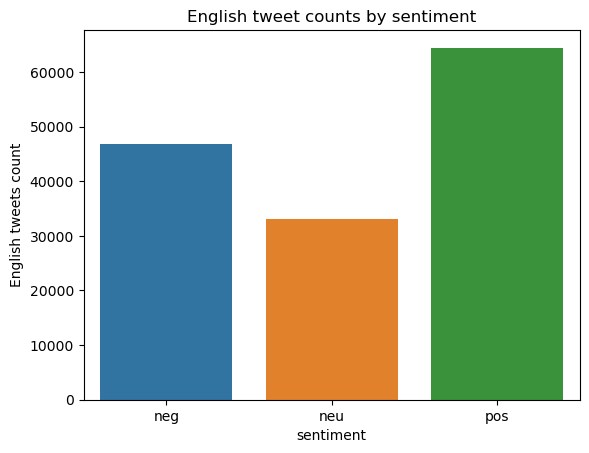

In [32]:
sns.barplot(data=sentiment_count, x='sentiment', y='tweet_id',hue='sentiment')
plt.xlabel('sentiment')
plt.ylabel('English tweets count')
plt.title('English tweet counts by sentiment')
plt.savefig("sentiment_count.png")

In [33]:
sentiment_by_president_count = merged_copy.groupby(['sentiment', 'presidential_candidate'])['tweet_id'].count().reset_index()
sentiment_by_president_count

,sentiment,presidential_candidate,tweet_id
0,neg,biden,14447
1,neg,trump,32289
2,neu,biden,13808
3,neu,trump,19221
4,pos,biden,29113
5,pos,trump,35323


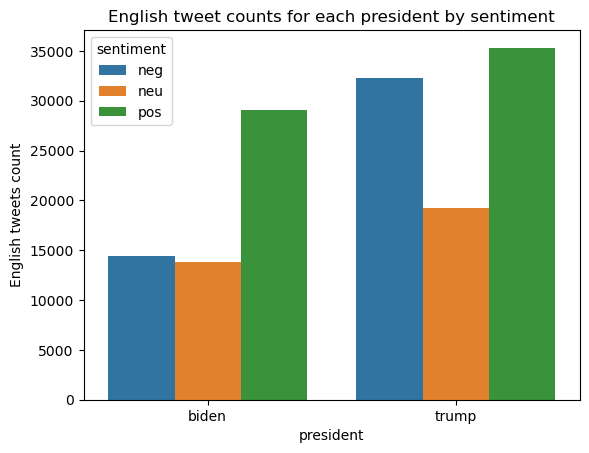

In [34]:
sns.barplot(data=sentiment_by_president_count, x='presidential_candidate', y='tweet_id',hue='sentiment')
plt.xlabel('president')
plt.ylabel('English tweets count')
plt.title('English tweet counts for each president by sentiment')
plt.savefig("sentiment_count_per_candidate.png")

In [35]:
tweets_in_two_most_tweets_states = merged_copy.loc[(merged_copy['state'] == 'New York') | (merged_copy['state'] == 'California')]

In [36]:
tweets_in_two_most_tweets_states

,created_at,tweet_id,tweet,likes,lat,long,city,country,continent,state,presidential_candidate,lang,sentiment
7,2020-10-15,1.316530e+18,Trump in Penn I saved suburbia I got rid of a ...,0.0,34.148399,-118.396188,Los Angeles,United States of America,North America,California,trump,en,neg
16,2020-10-15,1.316531e+18,or did just run out of drugs either way back t...,0.0,40.650102,-73.949583,New York,United States of America,North America,New York,trump,en,neu
26,2020-10-15,1.316532e+18,The people know is trying once again to politi...,0.0,40.712728,-74.006015,New York,United States of America,North America,New York,trump,en,neu
32,2020-10-15,1.316532e+18,Election is days away what better way to defac...,2.0,34.053691,-118.242766,Los Angeles,United States of America,North America,California,trump,en,pos
36,2020-10-15,1.316532e+18,Via It s been one faceplant after another as T...,0.0,40.712728,-74.006015,New York,United States of America,North America,New York,trump,en,pos
...,...,...,...,...,...,...,...,...,...,...,...,...,...
144187,2020-11-08,1.325584e+18,On what date can we officially start blaming a...,1.0,34.053691,-118.242766,Los Angeles,United States of America,North America,California,biden,en,neg
144188,2020-11-08,1.325584e+18,you have voted by mail before was your mail in...,0.0,40.712728,-74.006015,New York,United States of America,North America,New York,biden,en,neg
144191,2020-11-08,1.325585e+18,SUPPORTERS CELEBRATE IN WHITE PLAINS Crowd gat...,24.0,40.931210,-73.898747,Yonkers,United States of America,North America,New York,biden,en,pos
144195,2020-11-08,1.325587e+18,Hello Dems here is some evidence of mail in fraud,1.0,40.712728,-74.006015,New York,United States of America,North America,New York,biden,en,neg


In [37]:
sentiment_by_states_and_president = (
    tweets_in_two_most_tweets_states
    .groupby(['presidential_candidate', 'sentiment', 'state'])['tweet_id']
    .count()
    .reset_index()
    .rename(columns={
        'tweet_id': 'tweet counts'
    })
)

sentiment_by_states_and_president

,presidential_candidate,sentiment,state,tweet counts
0,biden,neg,California,2735
1,biden,neg,New York,3221
2,biden,neu,California,2674
3,biden,neu,New York,2726
4,biden,pos,California,5641
5,biden,pos,New York,6235
6,trump,neg,California,6288
7,trump,neg,New York,6691
8,trump,neu,California,4069
9,trump,neu,New York,3887


In [38]:
fig = px.bar(
    sentiment_by_states_and_president, 
    x="sentiment", 
    y="tweet counts", 
    color="presidential_candidate", 
    barmode="group", 
    facet_col="state",
    title="tweet counts for each president in California and New York",
    category_orders=
    {
        "sentiment": sentiment_by_states_and_president['sentiment'],
        "presidental_candidate": sentiment_by_states_and_president['presidential_candidate']
    }
)
fig.write_image("tweet_count_in_2_states.png")
fig.show()


In [39]:
tweets_by_date = (
    merged_copy
    .groupby('created_at')['tweet_id']
    .count()
    .reset_index()
    .rename(columns={
        'tweet_id': 'tweet counts'
    })
)

In [40]:
fig = px.line(tweets_by_date, x="created_at", y='tweet counts',
              hover_data={"tweet counts"},
              title='Number of English tweets during 2020 election')
fig.write_image("time_series_num_tweets_2020.png")
fig.show()

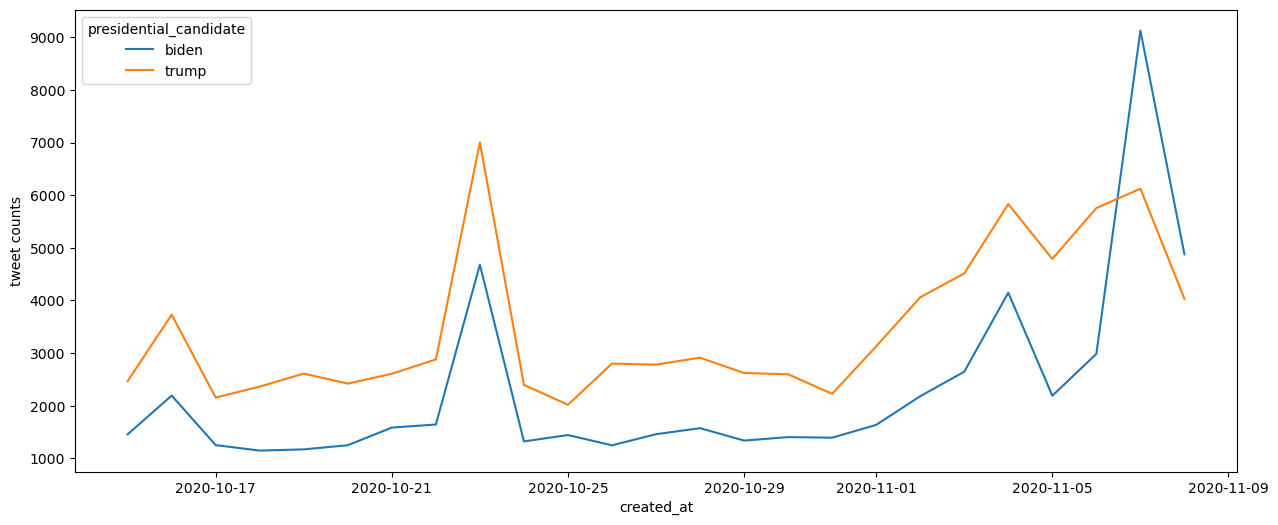

In [41]:
tweets_by_president = (
    merged_copy
    .groupby(['created_at', 'presidential_candidate'])['tweet_id']
    .count()
    .reset_index()
    .rename(columns={
        'tweet_id': 'tweet counts'
    })
)

plt.figure(figsize=(15, 6))

sns.lineplot(data=tweets_by_president, x='created_at', y='tweet counts', color='blue', hue='presidential_candidate')

plt.savefig("time_series_tweet_count_president.png")

<Figure size 3000x800 with 0 Axes>

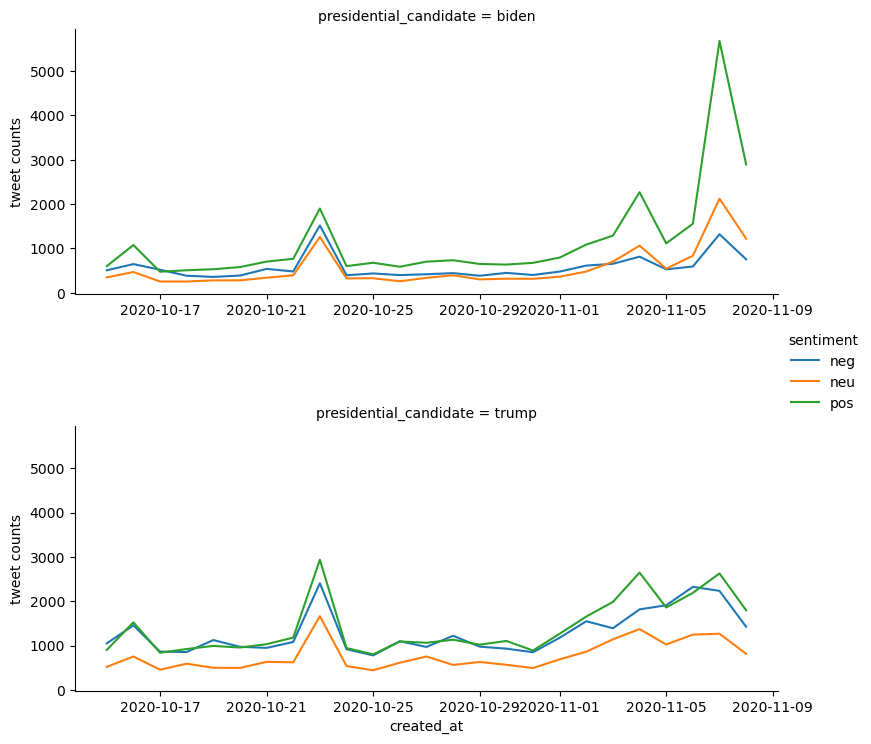

In [42]:
ts_sentiment_tweets_by_president = (
    merged_copy
    .groupby(['created_at', 'presidential_candidate', 'sentiment'])['tweet_id']
    .count()
    .reset_index()
    .rename(columns={
        'tweet_id': 'tweet counts'
    })
)

plt.figure(figsize=(30, 8))

g = sns.relplot(
    data=ts_sentiment_tweets_by_president, 
    x='created_at', 
    y='tweet counts', 
    hue='sentiment',
    row='presidential_candidate',
    kind='line',
    height=4, 
    aspect=2,
    facet_kws=dict(sharex=False)
    )

g.figure.subplots_adjust(hspace=0.5, top=0.9)

plt.savefig("time_series_sentiment_count_president.png")

In [43]:
shape_file = gep.read_file('./data/cb_2020_us_state_500k/cb_2020_us_state_500k.shp')
shape_file

,STATEFP,STATENS,AFFGEOID,GEOID,STUSPS,NAME,LSAD,ALAND,AWATER,geometry
0,35,00897535,0400000US35,35,NM,New Mexico,00,314198560935,726482115,"POLYGON ((-109.05017 31.48, -109.04984 31.4995..."
1,46,01785534,0400000US46,46,SD,South Dakota,00,196345992286,3383664203,"POLYGON ((-104.05788 44.9976, -104.05078 44.99..."
2,06,01779778,0400000US06,06,CA,California,00,403671196038,20294133830,"MULTIPOLYGON (((-118.60442 33.47855, -118.5987..."
3,21,01779786,0400000US21,21,KY,Kentucky,00,102282796080,2368025703,"MULTIPOLYGON (((-89.41728 36.49901, -89.40565 ..."
4,01,01779775,0400000US01,01,AL,Alabama,00,131175460655,4591915034,"MULTIPOLYGON (((-88.05338 30.50699, -88.05109 ..."
5,13,01705317,0400000US13,13,GA,Georgia,00,149486234922,4418749570,"MULTIPOLYGON (((-81.27939 31.30792, -81.27716 ..."
6,05,00068085,0400000US05,05,AR,Arkansas,00,134660850501,3121867339,"POLYGON ((-94.61792 36.49941, -94.61765 36.499..."
7,42,01779798,0400000US42,42,PA,Pennsylvania,00,115881934065,3397760687,"POLYGON ((-80.51989 40.90666, -80.51963 40.911..."
8,29,01779791,0400000US29,29,MO,Missouri,00,178052563675,2487215790,"POLYGON ((-95.77355 40.5782, -95.76853 40.5833..."
9,08,01779779,0400000US08,08,CO,Colorado,00,268418746964,1185766400,"POLYGON ((-109.06025 38.59933, -109.05954 38.7..."


In [44]:
tweet_states = merged_copy['state']
states = shape_file['NAME']
tweet_states[~tweet_states.isin(states)]

Series([], Name: state, dtype: object)

In [108]:

usa_state_geo_df = pd.merge(
    left = shape_file,
    right= merged_copy.groupby(['state'])['tweet_id'].count().reset_index(),
    left_on='NAME', 
    right_on='state',
    how='left'
).rename(columns={
    'tweet_id': 'english tweet count'
})

In [109]:
type(usa_state_geo_df)

geopandas.geodataframe.GeoDataFrame

In [110]:
usa_state_geo_df = usa_state_geo_df.dropna()

In [115]:

usa_state_geo_df.explore(
    zoom=1,
    cmap='viridis',
    column='english tweet count', 
    legend_kwds={'label': "USA 2020 Election English Tweet Counts By States"},
    legend=True,
    tooltip='state', 
    popup=True).save("usa_2020_election_tweet_count.html")